<a href="https://colab.research.google.com/github/RaisingEntropy/evolutionary_computation/blob/master/coevolution/coevolution_competitive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Competitive Coevolution: Predator vs Prey

In this notebook, we will implement a simple competitive coevolution system.

We will evolve two populations:
- Predators (try to catch prey)
- Prey (try to avoid predators)

Key idea:
Fitness depends on interactions between individuals, not an absolute objective.

## Key Concepts

- Each individual’s fitness depends on its opponents
- Populations evolve simultaneously
- This creates a moving fitness landscape
- Often leads to:
  - Arms races
  - Cycling behavior
  - Red Queen dynamics

We will simulate this in a simplified 1D environment.

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(0)
random.seed(0)

## Simplified Environment

We represent each individual as a single real number.

Interpretation:
- Predator and prey positions on a 1D line
- Distance between them determines interaction

Fitness:
- Predator: wants to minimize distance
- Prey: wants to maximize distance

In [3]:
# population initialization
pop_size = 30
generations = 50

def init_population():
    return np.random.uniform(-1, 1, pop_size)

predators = init_population()
prey = init_population()

## Fitness Function

We compute fitness based on pairwise interactions:

- Predator fitness increases when it is close to prey
- Prey fitness increases when it is far from predators

We approximate this by sampling interactions between individuals.

In [4]:
# evaluation function
def evaluate(predators, prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        for q in prey:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        for p in predators:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

## Evolution Operators

We use:
- Selection: keep the best half of each population
- Mutation: add Gaussian noise

No crossover is used here for simplicity.

In [5]:
# selection and mutation
def select_parents(pop, fitness, num_parents):
    idx = np.argsort(fitness)[-num_parents:]
    return pop[idx]

def reproduce(parents, pop_size, mutation_std=0.05):
    children = []
    while len(children) <= pop_size:
        parent = random.choice(parents)
        child = parent + np.random.normal(0, mutation_std)
        children.append(child)
    return np.array(children)

## Evolution Loop

Both populations evolve simultaneously:
1. Evaluate fitness
2. Select the best individuals
3. Apply mutation
4. Repeat

Observe how each population influences the other over time.

In [6]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate(predators, prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-20.966, Prey fitness=20.966
Gen 1: Pred fitness=-19.512, Prey fitness=19.512
Gen 2: Pred fitness=-19.632, Prey fitness=19.632
Gen 3: Pred fitness=-32.356, Prey fitness=32.356
Gen 4: Pred fitness=-46.697, Prey fitness=46.697
Gen 5: Pred fitness=-48.523, Prey fitness=48.523
Gen 6: Pred fitness=-49.497, Prey fitness=49.497
Gen 7: Pred fitness=-49.651, Prey fitness=49.651
Gen 8: Pred fitness=-48.998, Prey fitness=48.998
Gen 9: Pred fitness=-48.621, Prey fitness=48.621
Gen 10: Pred fitness=-48.741, Prey fitness=48.741
Gen 11: Pred fitness=-49.382, Prey fitness=49.382
Gen 12: Pred fitness=-49.298, Prey fitness=49.298
Gen 13: Pred fitness=-49.502, Prey fitness=49.502
Gen 14: Pred fitness=-49.714, Prey fitness=49.714
Gen 15: Pred fitness=-49.707, Prey fitness=49.707
Gen 16: Pred fitness=-50.432, Prey fitness=50.432
Gen 17: Pred fitness=-50.958, Prey fitness=50.958
Gen 18: Pred fitness=-51.380, Prey fitness=51.380
Gen 19: Pred fitness=-51.947, Prey fitness=51.947
Gen 20: Pr

## Observing the Dynamics

We now visualize how populations evolve over generations.

This helps us see:
- Movement of populations
- Clustering
- Possible oscillations

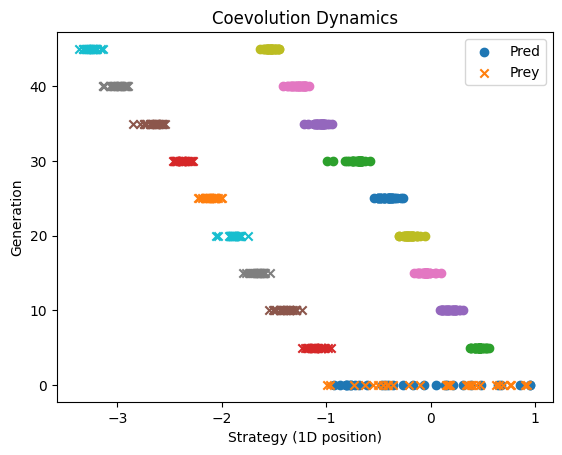

In [7]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 1 - Tournament Sampling
Modify the fitness evaluation so that each individual competes against a random subset of the opposite population instead of the full population.

Specifically:
- For each predator, sample k prey
- For each prey, sample k predators

Compare results with the original full evaluation.

Solutions here: https://github.com/giorgia-nadizar/evolution/blob/master/coevolution/solutions.py

In [8]:
# evaluation function
def evaluate_tournament(predators, prey, k = 10):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        prey_sample = np.random.choice(prey, k)
        for q in prey_sample:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        predator_sample = np.random.choice(predators, k)
        for p in predator_sample:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

In [9]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate_tournament(predators, prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-7.117, Prey fitness=7.396
Gen 1: Pred fitness=-7.007, Prey fitness=6.907
Gen 2: Pred fitness=-7.689, Prey fitness=7.353
Gen 3: Pred fitness=-8.865, Prey fitness=9.366
Gen 4: Pred fitness=-7.831, Prey fitness=7.693
Gen 5: Pred fitness=-6.912, Prey fitness=6.781
Gen 6: Pred fitness=-6.456, Prey fitness=6.343
Gen 7: Pred fitness=-6.584, Prey fitness=6.539
Gen 8: Pred fitness=-6.249, Prey fitness=6.161
Gen 9: Pred fitness=-6.124, Prey fitness=6.025
Gen 10: Pred fitness=-5.582, Prey fitness=5.636
Gen 11: Pred fitness=-5.576, Prey fitness=5.643
Gen 12: Pred fitness=-4.940, Prey fitness=5.072
Gen 13: Pred fitness=-4.945, Prey fitness=4.981
Gen 14: Pred fitness=-4.788, Prey fitness=4.663
Gen 15: Pred fitness=-4.933, Prey fitness=4.954
Gen 16: Pred fitness=-4.989, Prey fitness=4.981
Gen 17: Pred fitness=-4.993, Prey fitness=4.977
Gen 18: Pred fitness=-4.847, Prey fitness=4.864
Gen 19: Pred fitness=-4.848, Prey fitness=4.810
Gen 20: Pred fitness=-4.721, Prey fitness=4.775
Ge

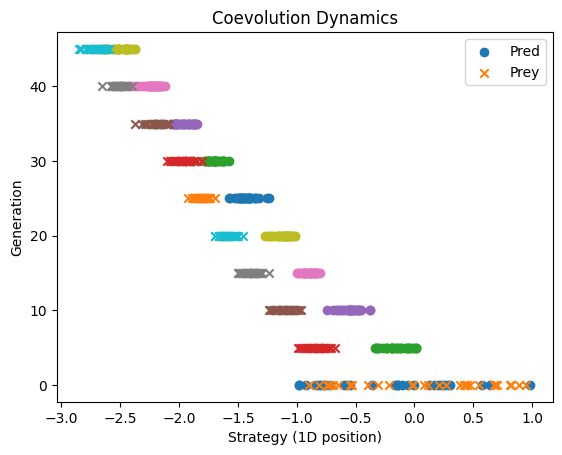

In [10]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 2 - Add a Hall of Fame
Maintain a Hall of Fame: store the best individuals from past generations.

When evaluating fitness:
- Include competition against Hall of Fame individuals

Solutions here: https://github.com/giorgia-nadizar/evolution/blob/master/coevolution/solutions.py

In [11]:
hall_of_fame_pred = []
hall_of_fame_prey = []

def update_hof(pop, fitness, hof, top_k=3):
    idx = np.argsort(fitness)[-top_k:]
    hof.extend(pop[idx])
    return hof

def evaluate_with_hof(predators, prey, hof_pred, hof_prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        opponents = list(prey) + hof_prey
        for q in opponents:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        opponents = list(predators) + hof_pred
        for p in opponents:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

In [12]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate_with_hof(predators, prey, hall_of_fame_pred, hall_of_fame_prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-21.616, Prey fitness=21.616
Gen 1: Pred fitness=-21.376, Prey fitness=21.376
Gen 2: Pred fitness=-14.771, Prey fitness=14.771
Gen 3: Pred fitness=-9.337, Prey fitness=9.337
Gen 4: Pred fitness=-5.722, Prey fitness=5.722
Gen 5: Pred fitness=-5.081, Prey fitness=5.081
Gen 6: Pred fitness=-5.373, Prey fitness=5.373
Gen 7: Pred fitness=-4.560, Prey fitness=4.560
Gen 8: Pred fitness=-4.696, Prey fitness=4.696
Gen 9: Pred fitness=-6.096, Prey fitness=6.096
Gen 10: Pred fitness=-6.306, Prey fitness=6.306
Gen 11: Pred fitness=-6.788, Prey fitness=6.788
Gen 12: Pred fitness=-6.550, Prey fitness=6.550
Gen 13: Pred fitness=-7.209, Prey fitness=7.209
Gen 14: Pred fitness=-6.875, Prey fitness=6.875
Gen 15: Pred fitness=-7.039, Prey fitness=7.039
Gen 16: Pred fitness=-6.625, Prey fitness=6.625
Gen 17: Pred fitness=-6.400, Prey fitness=6.400
Gen 18: Pred fitness=-5.823, Prey fitness=5.823
Gen 19: Pred fitness=-5.923, Prey fitness=5.923
Gen 20: Pred fitness=-5.131, Prey fitness=5.

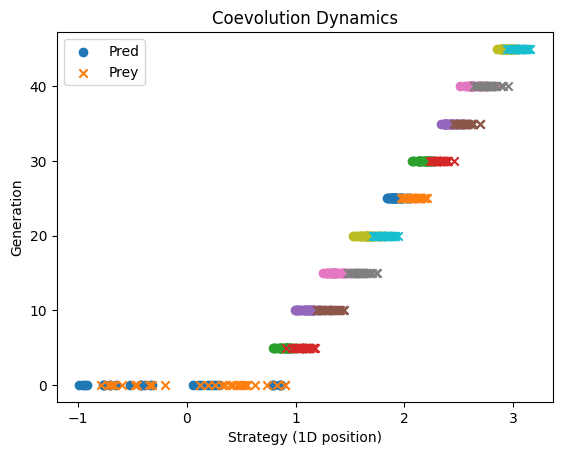

In [13]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 3: Extend Coevolution to 2D

So far, individuals were represented as 1D values.

In this exercise:
- Extend individuals to 2D positions: (x, y)
- Predators and prey move in a 2D space
- Fitness is based on Euclidean distance

Questions:
- How does spatial representation affect behavior?
- Do we observe clustering or separation?
- Does coevolution behave differently in 2D?

In [14]:
def init_population_2d():
    return np.random.uniform(-1, 1, (pop_size, 2))

predators = init_population_2d()
prey = init_population_2d()

In [15]:
def evaluate_2d(predators, prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        for q in prey:
            distance = np.linalg.norm(p - q)
            predator_fitness[i] += -distance

    for j, q in enumerate(prey):
        for p in predators:
            distance = np.linalg.norm(p - q)
            prey_fitness[j] += distance

    return predator_fitness, prey_fitness

In [16]:
def reproduce_2d(parents, pop_size, mutation_std=0.05):
    children = []
    while len(children) <= pop_size:
        parent = random.choice(parents)
        child = parent + np.random.normal(0, mutation_std, size=2)
        children.append(child)
    return np.array(children)

In [17]:
pred_history = []
prey_history = []

predators = init_population_2d()
prey = init_population_2d()

for gen in range(generations):
    pred_fit, prey_fit = evaluate_2d(predators, prey)

    pred_history.append((predators.copy(), gen))
    prey_history.append((prey.copy(), gen))

    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    predators = reproduce_2d(pred_parents, pop_size)
    prey = reproduce_2d(prey_parents, pop_size)

## Visualization with Temporal Color Encoding

Instead of plotting generations on the y-axis, we now:

- Use position (x, y) as the axes
- Encode generation using a color gradient

This allows us to see:
- How populations move over time
- Whether they converge or drift
- How strategies evolve temporally in space

In [18]:
def flatten_history(history):
    xs, ys, gens = [], [], []
    for positions, gen in history:
        for p in positions:
            xs.append(p[0])
            ys.append(p[1])
            gens.append(gen)
    return np.array(xs), np.array(ys), np.array(gens)

pred_x, pred_y, pred_g = flatten_history(pred_history)
prey_x, prey_y, prey_g = flatten_history(prey_history)

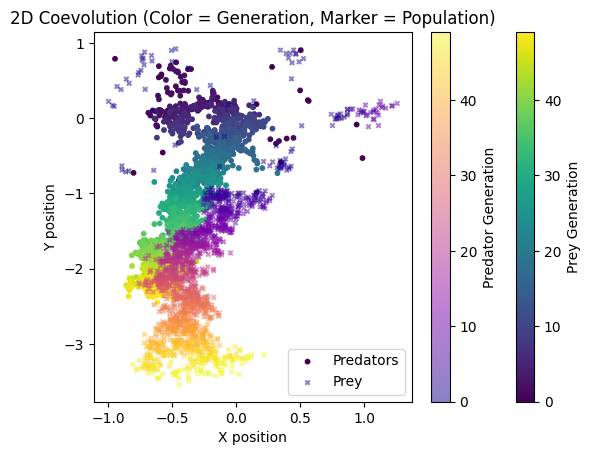

In [19]:
plt.figure()

# Predators: circle markers
plt.scatter(
    pred_x, pred_y,
    c=pred_g,
    cmap='viridis',
    s=10,
    marker='o',
    label="Predators",
)
plt.colorbar(label="Prey Generation")

# Prey: cross markers
plt.scatter(
    prey_x, prey_y,
    c=prey_g,
    cmap='plasma',
    s=10,
    marker='x',
    label="Prey",
    alpha=.5,
)
plt.colorbar(label="Predator Generation")

plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D Coevolution (Color = Generation, Marker = Population)")
plt.legend()
plt.show()